In [2]:
# ----------------------------------------------------------------------
# STEP 1: Install dependencies
# ----------------------------------------------------------------------
# Run this once (in Colab, put it in its own cell with the leading "!"):
# !pip install -q transformers torch pillow requests matplotlib

import requests
from io import BytesIO

import torch
from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification
import matplotlib.pyplot as plt

In [3]:

# ----------------------------------------------------------------------
# STEP 2: Load a pretrained ViT image classification model
# ----------------------------------------------------------------------
MODEL_NAME = "google/vit-base-patch16-224"   # ViT-Base, trained on ImageNet-1k

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
model = ViTForImageClassification.from_pretrained(MODEL_NAME)
model.eval()

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

C:\Users\Hp\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hp\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear

In [4]:
# ----------------------------------------------------------------------
# STEP 3: 5 sample images + their known ("ground truth") ImageNet class
# ----------------------------------------------------------------------
# These are official ImageNet-1k sample images, so the ground truth is
# known ahead of time and can be compared against the model's prediction.
IMAGES = [
    {
        "url": "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02123045_tabby.JPEG",
        "ground_truth": "tabby, tabby cat",
    },
    {
        "url": "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02099712_Labrador_retriever.JPEG",
        "ground_truth": "Labrador retriever",
    },
    {
        "url": "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02504458_African_elephant.JPEG",
        "ground_truth": "African elephant, Loxodonta africana",
    },
    {
        "url": "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n07747607_orange.JPEG",
        "ground_truth": "orange",
    },
    {
        "url": "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n03445777_golf_ball.JPEG",
        "ground_truth": "golf ball",
    },
]


In [5]:
def download_image(url: str) -> Image.Image:
    response = requests.get(url, timeout=15)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGB")

In [6]:
# ----------------------------------------------------------------------
# STEP 4: Run predictions
# ----------------------------------------------------------------------
results = []

for item in IMAGES:
    image = download_image(item["url"])

    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    confidence, predicted_idx = torch.max(probs, dim=-1)

    predicted_label = model.config.id2label[predicted_idx.item()]
    confidence_score = confidence.item()

    # A prediction "counts" as correct if the ground-truth phrase shares
    # a class label with the top prediction.
    is_correct = item["ground_truth"].split(",")[0].strip().lower() in predicted_label.lower()

    results.append({
        "image": image,
        "predicted_label": predicted_label,
        "confidence": confidence_score,
        "ground_truth": item["ground_truth"],
        "is_correct": is_correct,
    })

C:\Users\Hp\AppData\Local\Temp\ipykernel_7584\4156497754.py:18: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Hp\AppData\Local\Temp\ipykernel_7584\4156497754.py:18: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Hp\AppData\Local\Temp\ipykernel_7584\4156497754.py:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("vit_predictions.png", dpi=150, bbox_inches="tight")
C:\Users\Hp\AppData\Local\Temp\ipykernel_7584\4156497754.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("vit_predictions.png", dpi=150, bbox_inches="tight")
C:\Users\Hp\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Hp\anaconda3\Lib\site-packages\IPython\core

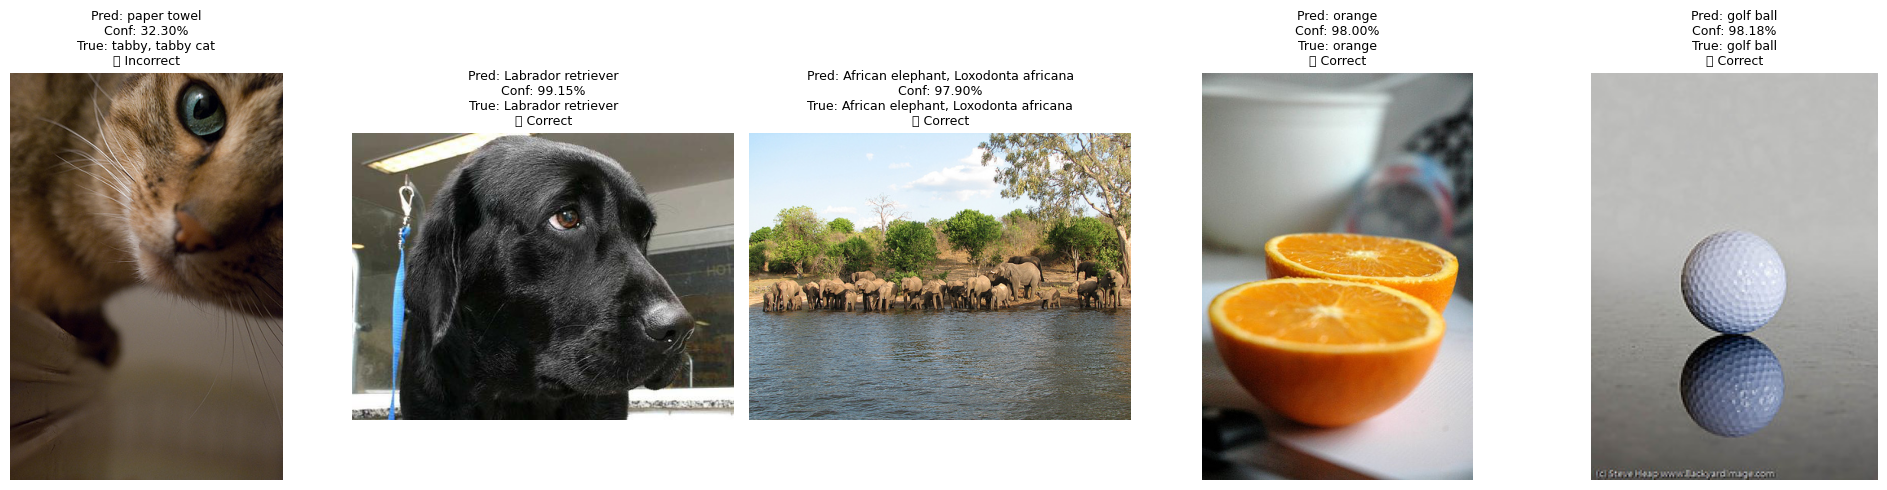

In [7]:
# ----------------------------------------------------------------------
# STEP 5: Display results (image + predicted class + confidence + correctness)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 5))

for ax, r in zip(axes, results):
    ax.imshow(r["image"])
    ax.axis("off")
    verdict = "✅ Correct" if r["is_correct"] else "❌ Incorrect"
    title = (
        f"Pred: {r['predicted_label']}\n"
        f"Conf: {r['confidence']*100:.2f}%\n"
        f"True: {r['ground_truth']}\n"
        f"{verdict}"
    )
    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.savefig("vit_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ----------------------------------------------------------------------
# STEP 6: Print a text summary table
# ----------------------------------------------------------------------
print(f"\n{'Ground Truth':30s} | {'Predicted Class':30s} | {'Confidence':10s} | Correct?")
print("-" * 90)
for r in results:
    print(
        f"{r['ground_truth']:30s} | {r['predicted_label']:30s} | "
        f"{r['confidence']*100:8.2f}% | {'Yes' if r['is_correct'] else 'No'}"
    )

accuracy = sum(r["is_correct"] for r in results) / len(results) * 100
print(f"\nOverall accuracy on these 5 images: {accuracy:.1f}%")


Ground Truth                   | Predicted Class                | Confidence | Correct?
------------------------------------------------------------------------------------------
tabby, tabby cat               | paper towel                    |    32.30% | No
Labrador retriever             | Labrador retriever             |    99.15% | Yes
African elephant, Loxodonta africana | African elephant, Loxodonta africana |    97.90% | Yes
orange                         | orange                         |    98.00% | Yes
golf ball                      | golf ball                      |    98.18% | Yes

Overall accuracy on these 5 images: 80.0%
